# K-Nearest Neighbors (KNN)
**Task:** Classification | **Target:** Sleep Disorder


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load & Preprocess

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df = df.drop('Person ID', axis=1)
df = df.drop('Blood Pressure', axis=1)

le = LabelEncoder()
df['Gender']        = le.fit_transform(df['Gender'])
df['Occupation']    = le.fit_transform(df['Occupation'])
df['BMI Category']  = le.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

le_disorder = LabelEncoder()
df['Sleep Disorder'] = le_disorder.fit_transform(df['Sleep Disorder'])

X = df.drop(['Sleep Disorder', 'Quality of Sleep'], axis=1)
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN is distance-based — scaling is important
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Classes:', le_disorder.classes_)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Classes: ['Insomnia' 'None' 'Sleep Apnea']
Train: (299, 9) | Test: (75, 9)


## Find Best K

Best K: 8 with accuracy: 0.8667


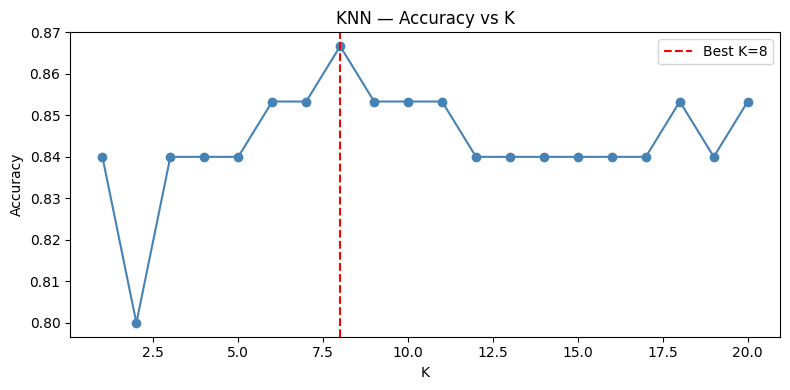

In [3]:
k_range = range(1, 21)
accuracies = []
#testing all the k from 1 to 20 
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_s)))

# take the hyperparam k with the best accuracy
best_k = k_range[np.argmax(accuracies)]
print(f'Best K: {best_k} with accuracy: {max(accuracies):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K')
plt.legend()
plt.tight_layout()
plt.show()

## Train Model with Best K

In [7]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

## Evaluation

In [8]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_disorder.classes_))

Accuracy: 0.8667

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.70      0.88      0.78        16
        None       0.93      0.95      0.94        43
 Sleep Apnea       0.91      0.62      0.74        16

    accuracy                           0.87        75
   macro avg       0.85      0.82      0.82        75
weighted avg       0.88      0.87      0.86        75



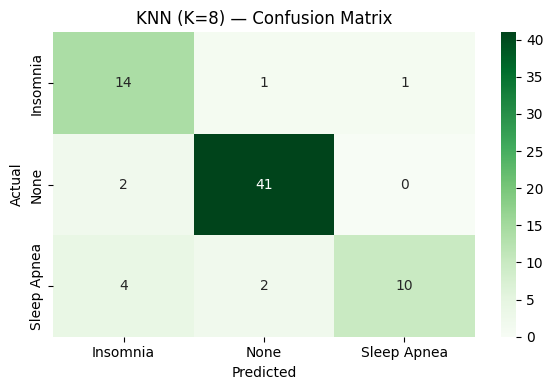

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_disorder.classes_,
            yticklabels=le_disorder.classes_)
plt.title(f'KNN (K={best_k}) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()